# SAC arrival_v2 — Strict-Control Topology × Geometry Visualization (Nature style)

**作用**：把 [`docs/arrival_v2_experiment_report.md`](../docs/arrival_v2_experiment_report.md) §7 中**严格控制 4-way 主对比**做成发表级别 figures。

**控制变量**（[报告 §7](../docs/arrival_v2_experiment_report.md)）：`s1 / k4 / arrival_v2 / U=1.5 / target=1.5 / seed=42 / 1M / num_envs=6`，唯一变量 = **topology × geometry**。

| key | 报告节 | benchmark | topology | geometry | 5/5 gate |
|---|---|---|---|---|---|
| `single_cross`    | §7.1 | `single_u15_cross_tgt15`    | single | cross_stream | PASS（borderline，OOB 0.10） |
| `single_upstream` | §7.2 | `single_u15_upstream_tgt15` | single | upstream     | PASS |
| `tandem`          | §7.3 | `tandem_u15_upstream_tgt15` | double tandem (G/D=3.5) | upstream | PASS |
| `sbs`             | §7.4 | `sbs_u15_upstream_tgt15`    | double sbs (G/D=3.5)    | upstream | PASS |

**Figure 输出**（`figures/arrival_v2_strict_control_validation/`）：

| 文件 | 内容 | 用途 |
|---|---|---|
| `fig1_training_curves.{pdf,png}` | 4 场景 × 4 metric 训练曲线网格 | 主要：收敛形状对照 |
| `fig2_final_eval_summary.{pdf,png}` | 30-ep deterministic eval 对照条形 | 主要：每个场景的终态质量 |
| `fig3_<i>_<key>.{pdf,png}` (×4) | 单场景轨迹 × 时均流场（一图一场景） | 主要：策略空间形状 |
| `fig4_animation_<scenario>.gif` (×4) | 每场景一张 GIF：轨迹 × 时变涡量场 | 副：动态展示 |

**与旧 viz notebook 的区别**：
- 旧 [`sac_arrival_v2_topology_visualization_tmp.ipynb`](sac_arrival_v2_topology_visualization_tmp.ipynb) 用 `cross_u10` (U=1.0/s0/seed=46) + `p1_v6` (seed=46/1.5M) 作 reference baseline，与 tandem/sbs 不严格可比；
- 本 notebook 4 组完全 **strict control** —— 所有非控变量统一固定，仅 topology × geometry 变化。

**风格**：Nature 单栏宽度上限 **138 mm**。所有 figure 严格 138 mm，72-pt 字号或更小，sans-serif，发表灰阶可读。

**容错**：未完成的场景会被自动 skip（带 `[skip]` log），完成后重跑同 cell 即填回。

**运行环境**：Colab Pro+（Drive 挂载 + GPU 可选；推理用 CPU 也能跑）。本 notebook 不依赖训练，只依赖已落地的 `experiments/...` + `checkpoints/...`。

## 0. Env sanity

In [1]:
!nvidia-smi 2>/dev/null | head -10 || echo 'no gpu (cpu inference is fine)'
import sys
import torch
print(f'python={sys.version.split()[0]}  torch={torch.__version__}  '
      f'cuda={torch.cuda.is_available()}')

python=3.12.13  torch=2.10.0+cpu  cuda=False


## 1. Mount Drive + cwd

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

REPO_DIR = '/content/drive/MyDrive/Colab Notebooks/new_offRL/rl_v2_5'
%cd $REPO_DIR

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/new_offRL/rl_v2_5


## 2. Imports + figure output dir

`imageio` 用来写 GIF。Colab 自带；本地 `mytorch1` 也已装。

In [3]:
import json
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Circle
import imageio.v2 as imageio

# Repo modules (avoid heavy import errors if env mis-set)
from auv_nav.flow import WakeField

FIG_DIR = Path('figures/arrival_v2_strict_control_validation')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'[OK] figure dir: {FIG_DIR.resolve()}')

[OK] figure dir: /content/drive/MyDrive/Colab Notebooks/new_offRL/rl_v2_5/figures/arrival_v2_strict_control_validation


## 3. Nature 风格常量

- 宽度 **138 mm** = 5.433 in（Nature 单栏≤89 mm，跨双栏≤183 mm；此处取用户指定的 138 mm）
- 字号：panel label 8 pt / panel title 7 pt / axis label 7 pt / tick 6 pt
- 字体 sans-serif（Helvetica / Arial fallback）
- Linewidth 0.8；spine 0.5
- DPI 600（PDF 矢量；PNG 600 dpi 印刷）
- 4 场景调色板（按 topology × geometry 安排，色盲可读）：
  - `single_cross` → tab:blue（unique geometry）
  - `single_upstream` → tab:orange
  - `tandem` → tab:green
  - `sbs` → tab:red

In [4]:
MM_PER_INCH = 25.4
FIGURE_WIDTH_MM = 138.0
FIGURE_WIDTH_IN = FIGURE_WIDTH_MM / MM_PER_INCH  # 5.433 in

PANEL_LABEL_FS = 8.0
PANEL_TITLE_FS = 7.0
AXIS_LABEL_FS = 7.0
TICK_FS = 6.0
LEGEND_FS = 6.0

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': AXIS_LABEL_FS,
    'axes.labelsize': AXIS_LABEL_FS,
    'axes.titlesize': PANEL_TITLE_FS,
    'xtick.labelsize': TICK_FS,
    'ytick.labelsize': TICK_FS,
    'legend.fontsize': LEGEND_FS,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.0,
    'ytick.major.size': 2.0,
    'lines.linewidth': 0.8,
    'figure.dpi': 100,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
    'pdf.fonttype': 42,   # embed TrueType (editable in Illustrator)
    'ps.fonttype': 42,
})

SCENARIO_COLORS = {
    'single_cross':    '#1f77b4',  # tab:blue   (unique geometry: cross_stream)
    'single_upstream': '#ff7f0e',  # tab:orange (single + upstream baseline)
    'tandem':          '#2ca02c',  # tab:green  (double tandem + upstream)
    'sbs':             '#d62728',  # tab:red    (double sbs + upstream)
}

def save_figure(fig, name_stem):
    """Save figure as both .pdf (vector) and .png (raster) at 138 mm width."""
    for ext in ('pdf', 'png'):
        path = FIG_DIR / f'{name_stem}.{ext}'
        fig.savefig(path)
        print(f'  [saved] {path}')

print(f'[OK] figure width = {FIGURE_WIDTH_IN:.3f} in ({FIGURE_WIDTH_MM:.0f} mm)')

[OK] figure width = 5.433 in (138 mm)


## 4. 场景 registry + 自动可用性探测

每个场景定义：`run_dir`（实验落点，含 `results/`）、`flow_path`、benchmark `manifest`、display label / color。

运行此 cell 时探测哪些场景已完成（`final_eval.json` 存在）/ 哪些还在跑。下游 figure 只用 `available=True` 的。

**注意**：`single_cross` 与 `single_upstream` 共用同一 flow file（单柱 U=1.5 / Re=250），仅 episode reset_options 的 `task_geometry` 不同。

In [5]:
SCENARIOS = [
    {
        'key': 'single_cross',
        'label': 'Single, cross-stream',
        'topology': 'single',
        'run_dir':  Path('experiments/arrival_v2_prototype/single_u15_cross_tgt15/arrival_v2/sac_vanilla/s1_k4/seed_42'),
        'flow_path': Path('wake_data/wake_v8_U1p50_Re250_D12p00_dx0p60_Ti5pct_1200f_roi.npy'),
        'manifest':  Path('benchmarks/single_u15_cross_tgt15.json'),
        'color': SCENARIO_COLORS['single_cross'],
    },
    {
        'key': 'single_upstream',
        'label': 'Single, upstream',
        'topology': 'single',
        'run_dir':  Path('experiments/arrival_v2_prototype/single_u15_upstream_tgt15/arrival_v2/sac_vanilla/s1_k4/seed_42'),
        'flow_path': Path('wake_data/wake_v8_U1p50_Re250_D12p00_dx0p60_Ti5pct_1200f_roi.npy'),
        'manifest':  Path('benchmarks/single_u15_upstream_tgt15.json'),
        'color': SCENARIO_COLORS['single_upstream'],
    },
    {
        'key': 'tandem',
        'label': 'Tandem  G/D=3.5,  upstream',
        'topology': 'tandem',
        'run_dir':  Path('experiments/arrival_v2_prototype/tandem_u15_upstream_tgt15/arrival_v2/sac_vanilla/s1_k4/seed_42'),
        'flow_path': Path('wake_data/wake_tandem_G35_v8_U1p50_Re250_D12p00_dx0p60_Ti5pct_1200f_roi.npy'),
        'manifest':  Path('benchmarks/tandem_u15_upstream_tgt15.json'),
        'color': SCENARIO_COLORS['tandem'],
    },
    {
        'key': 'sbs',
        'label': 'Side-by-side  G/D=3.5,  upstream',
        'topology': 'side_by_side',
        'run_dir':  Path('experiments/arrival_v2_prototype/sbs_u15_upstream_tgt15/arrival_v2/sac_vanilla/s1_k4/seed_42'),
        'flow_path': Path('wake_data/wake_sbs_G35_v8_U1p50_Re250_D12p00_dx0p60_Ti5pct_1200f_roi.npy'),
        'manifest':  Path('benchmarks/sbs_u15_upstream_tgt15.json'),
        'color': SCENARIO_COLORS['sbs'],
    },
]

for sc in SCENARIOS:
    final_eval = sc['run_dir'] / 'results' / 'final_eval.json'
    eval_log = sc['run_dir'] / 'results' / 'eval_log.csv'
    trainer_state = sc['run_dir'] / 'trainer_state.json'
    sc['available_final'] = final_eval.exists()
    sc['available_evallog'] = eval_log.exists()
    sc['available_trainerstate'] = trainer_state.exists()
    sc['available_flow'] = sc['flow_path'].exists()
    sc['available_manifest'] = sc['manifest'].exists()
    sc['available_full'] = all([
        sc['available_final'], sc['available_evallog'],
        sc['available_trainerstate'], sc['available_flow'], sc['available_manifest'],
    ])

rows = []
for sc in SCENARIOS:
    rows.append({
        'key': sc['key'],
        'final_eval': '✓' if sc['available_final'] else '✗',
        'eval_log': '✓' if sc['available_evallog'] else '✗',
        'trainer_state': '✓' if sc['available_trainerstate'] else '✗',
        'flow': '✓' if sc['available_flow'] else '✗',
        'manifest': '✓' if sc['available_manifest'] else '✗',
        'full_pipeline': '✓' if sc['available_full'] else '✗',
    })

print(pd.DataFrame(rows).to_string(index=False))
available_keys = [sc['key'] for sc in SCENARIOS if sc['available_full']]
print()
print(f'[summary] {len(available_keys)} / 4 scenarios fully available: {available_keys}')

            key final_eval eval_log trainer_state flow manifest full_pipeline
   single_cross          ✓        ✓             ✓    ✓        ✓             ✓
single_upstream          ✓        ✓             ✓    ✓        ✓             ✓
         tandem          ✓        ✓             ✓    ✓        ✓             ✓
            sbs          ✓        ✓             ✓    ✓        ✓             ✓

[summary] 4 / 4 scenarios fully available: ['single_cross', 'single_upstream', 'tandem', 'sbs']


## 5. Figure 1 — 训练曲线（4 场景 × 4 metric）

2×2 网格，每 panel 一个 metric，4 条线对应 4 场景。Metric 选取：
- (a) `eval_success_rate` — 主指标（gate 阈 0.85 虚线参考）
- (b) `eval_safety_cost` — arrival_v2 vs efficiency_v2 的核心区别（不应飙）
- (c) `eval_time_s` — 任务效率（time-to-goal）
- (d) `eval_progress_ratio` — 推进质量

每条线轻微 EMA 平滑（half-life=2 eval points），保留原始噪声 reference。

  [saved] figures/arrival_v2_strict_control_validation/fig1_training_curves.pdf
  [saved] figures/arrival_v2_strict_control_validation/fig1_training_curves.png


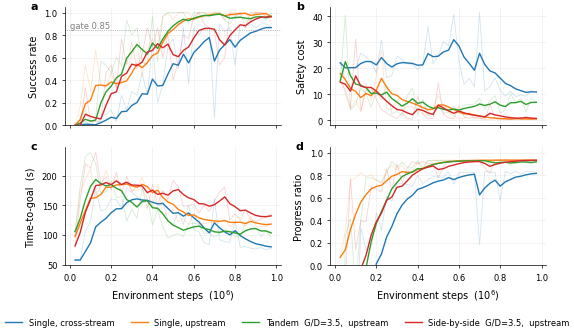

In [6]:
def ema(values, half_life=2):
    if len(values) == 0:
        return values
    alpha = 1 - 0.5 ** (1 / max(half_life, 1e-6))
    out = np.empty_like(values, dtype=float)
    out[0] = values[0]
    for i in range(1, len(values)):
        out[i] = alpha * values[i] + (1 - alpha) * out[i - 1]
    return out

fig1, axes = plt.subplots(
    2, 2,
    figsize=(FIGURE_WIDTH_IN, FIGURE_WIDTH_IN * 0.62),
    sharex=True,
)
panels = [
    ('eval_success_rate',   'Success rate',          (0.0, 1.05)),
    ('eval_safety_cost',    'Safety cost',           None),
    ('eval_time_s',         'Time-to-goal  (s)',     None),
    ('eval_progress_ratio', 'Progress ratio',        (0.0, 1.05)),
]
panel_letters = ['a', 'b', 'c', 'd']

for ax, (col, ylabel, ylim), letter in zip(axes.flat, panels, panel_letters):
    for sc in SCENARIOS:
        if not sc['available_evallog']:
            continue
        df = pd.read_csv(sc['run_dir'] / 'results' / 'eval_log.csv')
        if col not in df.columns or len(df) == 0:
            continue
        x = df['env_step'].values / 1e6
        y = df[col].values
        ax.plot(x, y, color=sc['color'], alpha=0.20, lw=0.6)
        ax.plot(x, ema(y, half_life=2), color=sc['color'], lw=1.0, label=sc['label'])
    ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_FS)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.text(-0.16, 1.05, letter, transform=ax.transAxes,
            fontsize=PANEL_LABEL_FS, fontweight='bold', va='top', ha='left')
    ax.grid(True, alpha=0.25, lw=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax in axes[1, :]:
    ax.set_xlabel('Environment steps  (10$^6$)', fontsize=AXIS_LABEL_FS)

axes[0, 0].axhline(0.85, color='gray', ls=':', lw=0.5)
axes[0, 0].text(0.02, 0.86, 'gate 0.85', fontsize=LEGEND_FS, color='gray',
                transform=axes[0, 0].get_yaxis_transform())

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig1.legend(
        handles, labels,
        loc='lower center', ncol=min(len(handles), 4), fontsize=LEGEND_FS,
        frameon=False, bbox_to_anchor=(0.5, -0.02),
    )

fig1.tight_layout(rect=(0, 0.04, 1, 1))
save_figure(fig1, 'fig1_training_curves')
plt.show()

## 6. Figure 2 — Final eval summary（30-ep deterministic）

横向条形图，每场景 4 个条：success / 1−OOB / `path_efficiency` / `progress_ratio`。零线 + gate 0.85 红线 reference。Legend 放在图下方避免遮挡数据。

  [saved] figures/arrival_v2_strict_control_validation/fig2_final_eval_summary.pdf
  [saved] figures/arrival_v2_strict_control_validation/fig2_final_eval_summary.png


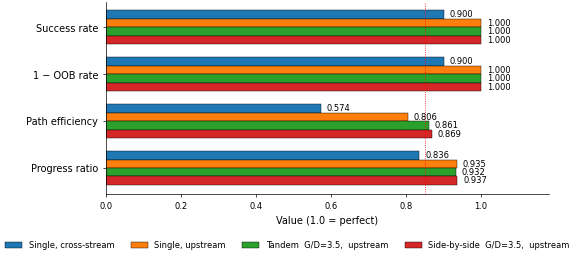


[final eval table]
            key  success  1-OOB  path_eff  progress  safety_cost     time_s                             term
   single_cross      0.9    0.9  0.574269  0.835967     7.344237  79.130000 {'goal': 27, 'out_of_bounds': 3}
single_upstream      1.0    1.0  0.806006  0.935432     0.142479 118.183333                     {'goal': 30}
         tandem      1.0    1.0  0.861446  0.932121     6.847983  96.300000                     {'goal': 30}
            sbs      1.0    1.0  0.868580  0.937110     0.586307 127.416667                     {'goal': 30}


In [7]:
summary_rows = []
for sc in SCENARIOS:
    if not sc['available_final']:
        continue
    fe = json.loads((sc['run_dir'] / 'results' / 'final_eval.json').read_text(encoding='utf-8'))
    n_eps = float(fe.get('num_eval_episodes', 30))
    counts = fe.get('eval_termination_counts', {})
    oob_rate = float(counts.get('out_of_bounds', 0)) / max(n_eps, 1.0)
    summary_rows.append({
        'key': sc['key'],
        'label': sc['label'],
        'color': sc['color'],
        'success': float(fe.get('eval_success_rate', 0.0)),
        'one_minus_oob': 1.0 - oob_rate,
        'path_efficiency': float(fe.get('eval_path_efficiency', 0.0)),
        'progress_ratio': float(fe.get('eval_progress_ratio', 0.0)),
        'safety_cost': float(fe.get('eval_safety_cost', 0.0)),
        'time_s': float(fe.get('eval_time_s', 0.0)),
        'termination': counts,
    })

if not summary_rows:
    print('[skip] no final_eval.json available yet for any scenario')
else:
    metrics_to_plot = [
        ('success',         'Success rate'),
        ('one_minus_oob',   '1 − OOB rate'),
        ('path_efficiency', 'Path efficiency'),
        ('progress_ratio',  'Progress ratio'),
    ]
    n_metric = len(metrics_to_plot)
    n_scen = len(summary_rows)
    fig2, ax = plt.subplots(
        figsize=(FIGURE_WIDTH_IN, FIGURE_WIDTH_IN * 0.48),
    )
    bar_h = 0.18
    y_positions = np.arange(n_metric)
    for i, row in enumerate(summary_rows):
        offsets = (i - (n_scen - 1) / 2.0) * bar_h
        values = [row[m] for m, _ in metrics_to_plot]
        ax.barh(
            y_positions + offsets, values,
            height=bar_h, color=row['color'], label=row['label'],
            edgecolor='black', linewidth=0.3,
        )
        for j, v in enumerate(values):
            ax.text(
                min(v + 0.015, 1.05), y_positions[j] + offsets, f'{v:.3f}',
                fontsize=LEGEND_FS, va='center', ha='left',
            )
    ax.axvline(0.85, color='red', ls=':', lw=0.6)
    ax.set_yticks(y_positions)
    ax.set_yticklabels([m[1] for m in metrics_to_plot], fontsize=AXIS_LABEL_FS)
    ax.set_xlim(0, 1.18)
    ax.set_xlabel('Value (1.0 = perfect)', fontsize=AXIS_LABEL_FS)
    ax.invert_yaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend below the plot (mirror fig1 pattern, keep axes uncluttered)
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        fig2.legend(
            handles, labels,
            loc='lower center', ncol=min(len(handles), 4), fontsize=LEGEND_FS,
            frameon=False, bbox_to_anchor=(0.5, -0.02),
        )
    fig2.tight_layout(rect=(0, 0.06, 1, 1))
    save_figure(fig2, 'fig2_final_eval_summary')
    plt.show()

    print()
    print('[final eval table]')
    table_df = pd.DataFrame([{
        'key': r['key'],
        'success': r['success'],
        '1-OOB': r['one_minus_oob'],
        'path_eff': r['path_efficiency'],
        'progress': r['progress_ratio'],
        'safety_cost': r['safety_cost'],
        'time_s': r['time_s'],
        'term': str(r['termination']),
    } for r in summary_rows])
    print(table_df.to_string(index=False))

## 7. SAC rollout helper — load checkpoint + run 1 episode collecting trajectory

实现：
1. 读 `trainer_state.json` 拿 SACConfig + agent_path + obs/env config（probe / history / objective / target_speed / task_geometry）
2. 用 `make_planar_env(...)` 重建 env
3. `SACAgent(SACConfig(**...)).load(<agent_file>)`
4. 从 benchmark manifest 第一个 episode 取 `reset_options`
5. Step 循环采集 `positions / headings / times / flow_times / cum_rewards / actions` 等

返回 episode dict（兼容下游 figure 3 / figure 4）。

使用 `deterministic=True`（与 `evaluate_agent` 一致）。

In [8]:
from auv_nav.sac import SACAgent, SACConfig
from scripts.train_utils import make_planar_env, load_trainer_state, extract_env_config_overrides

def rollout_sac_agent(scenario, episode_idx=0, max_steps=2000, device='cpu'):
    """Load a trained SAC checkpoint and roll out one benchmark episode.

    Returns dict with arrays (length N = num control steps + 1):
        positions    (N, 2)    body x,y in metres   (info['position_xy_m'])
        headings     (N,)      psi rad              (info['psi_rad'])
        distances    (N,)      distance to goal     (info['distance_to_goal_m'])
        times        (N,)      sim seconds          (info['elapsed_time_s'])
        flow_times   (N,)      wake time            (info['flow_time_s'])
        rewards      (N-1,)    per-step reward
        cum_rewards  (N,)      cumulative reward (starts 0)
        success      bool
        reason       str (termination reason)
        env          PlanarRemusEnv  (wrapped or not, for downstream wf access)
        start_xy     (2,)   info['start_xy_m']
        goal_xy      (2,)   info['goal_xy_m']
        goal_radius  float  env.unwrapped.config.goal_radius_m
    """
    run_dir = scenario['run_dir']
    if not (run_dir / 'trainer_state.json').exists():
        raise FileNotFoundError(f'no trainer_state for {scenario["key"]}')

    trainer_state = load_trainer_state(str(run_dir))

    # locate the actual .pt agent (best > final > latest)
    agent_relative = (
        trainer_state.get('best_agent_path')
        or trainer_state.get('final_agent_path')
        or trainer_state.get('latest_agent_path')
        or trainer_state.get('agent_path')
    )
    if agent_relative is None:
        raise RuntimeError(f'no agent file recorded in trainer_state for {scenario["key"]}')
    # trainer_state stores save_dir-relative paths
    agent_file = (run_dir / agent_relative).resolve()
    if not agent_file.exists():
        raise FileNotFoundError(f'agent file missing: {agent_file}')

    # rebuild env exactly as training had it
    env_cfg_overrides = extract_env_config_overrides(trainer_state)
    history_length = int(trainer_state.get('history_length', 1) or 1)
    probe_layout = trainer_state.get('probe_layout', 's0')
    flow_path = trainer_state.get('flow_path', str(scenario['flow_path']))

    env = make_planar_env(
        flow_path,
        history_length=history_length,
        probe_layout=probe_layout,
        env_config_overrides=env_cfg_overrides,
    )

    # construct + load agent
    agent_cfg_dict = trainer_state['agent_config']
    agent = SACAgent(SACConfig(**agent_cfg_dict), device=device)
    agent.load(str(agent_file))

    # pull the requested benchmark episode for a deterministic start state
    manifest = json.loads(scenario['manifest'].read_text(encoding='utf-8'))
    episodes = manifest['episodes']
    ep_meta = episodes[episode_idx % len(episodes)]
    reset_options = dict(ep_meta['reset_options'])
    seed = int(ep_meta['seed'])

    obs, info = env.reset(seed=seed, options=reset_options)
    policy_state = agent.reset_policy_state()

    positions   = [info['position_xy_m'].copy()]
    headings    = [float(info['psi_rad'])]
    distances   = [float(info['distance_to_goal_m'])]
    times       = [float(info['elapsed_time_s'])]
    flow_times  = [float(info['flow_time_s'])]
    rewards     = []
    cum_rewards = [0.0]

    success = False
    reason = 'incomplete'

    for _ in range(max_steps):
        action, policy_state = agent.act(obs, policy_state, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        rewards.append(float(reward))
        cum_rewards.append(cum_rewards[-1] + float(reward))
        positions.append(info['position_xy_m'].copy())
        headings.append(float(info['psi_rad']))
        distances.append(float(info['distance_to_goal_m']))
        times.append(float(info['elapsed_time_s']))
        flow_times.append(float(info['flow_time_s']))
        if terminated or truncated:
            success = bool(info.get('success', terminated))
            reason = str(info.get('reason', 'goal' if success else 'timeout'))
            break

    env_unwrapped = env.unwrapped if hasattr(env, 'unwrapped') else env
    start_xy = np.asarray(info.get('start_xy_m', positions[0]), dtype=np.float32)
    goal_xy = np.asarray(info.get('goal_xy_m', reset_options.get('goal_xy', [0.0, 0.0])),
                         dtype=np.float32)
    goal_radius = float(getattr(env_unwrapped.config, 'goal_radius_m', 4.0))

    return {
        'positions':   np.asarray(positions, dtype=np.float32),
        'headings':    np.asarray(headings, dtype=np.float32),
        'distances':   np.asarray(distances, dtype=np.float32),
        'times':       np.asarray(times, dtype=np.float32),
        'flow_times':  np.asarray(flow_times, dtype=np.float32),
        'rewards':     np.asarray(rewards, dtype=np.float32),
        'cum_rewards': np.asarray(cum_rewards, dtype=np.float32),
        'success':     success,
        'reason':      reason,
        'env':         env,
        'start_xy':    start_xy,
        'goal_xy':     goal_xy,
        'goal_radius': goal_radius,
        'episode_id':  ep_meta.get('episode_id', f'ep_{episode_idx:04d}'),
    }

print('[OK] rollout_sac_agent defined')

[OK] rollout_sac_agent defined


### 7.1 跑 4 个 rollout（cache 到 `EPISODES`）

用 benchmark manifest 第 0 号 episode（每个 manifest 都是固定 seed/start/goal/flow_time，确保可复现）。Episode_idx 可改 0–29 选不同测试 episode。

In [9]:
EPISODE_IDX = 0   # 改这里看不同 manifest episode (0-29)
MAX_STEPS = 2000

EPISODES = {}
for sc in SCENARIOS:
    if not sc['available_full']:
        print(f'[skip {sc["key"]}] not all artefacts present')
        continue
    print(f'[rollout {sc["key"]}] ...', flush=True)
    try:
        ep = rollout_sac_agent(sc, episode_idx=EPISODE_IDX, max_steps=MAX_STEPS, device='cpu')
        EPISODES[sc['key']] = ep
        n_steps = len(ep['positions']) - 1
        dist0 = float(np.linalg.norm(ep['positions'][0] - ep['goal_xy']))
        distN = float(np.linalg.norm(ep['positions'][-1] - ep['goal_xy']))
        print(
            f'  -> {ep["reason"]:>10s}  steps={n_steps:>4d}  '
            f'd0={dist0:6.1f} m  dN={distN:6.1f} m  '
            f'cum_R={ep["cum_rewards"][-1]:7.2f}'
        )
    except Exception as e:
        print(f'  [FAIL {sc["key"]}] {type(e).__name__}: {e}')

print()
print(f'[summary] EPISODES has {len(EPISODES)} / 4 scenarios cached')

[rollout single_cross] ...
  ->       goal  steps= 118  d0=  41.2 m  dN=   4.0 m  cum_R= 141.46
[rollout single_upstream] ...
  ->       goal  steps= 329  d0=  85.5 m  dN=   4.0 m  cum_R= 144.24
[rollout tandem] ...
  ->       goal  steps= 111  d0=  53.9 m  dN=   4.0 m  cum_R= 145.16
[rollout sbs] ...
  ->       goal  steps= 185  d0=  62.7 m  dN=   3.9 m  cum_R= 144.93

[summary] EPISODES has 4 / 4 scenarios cached


## 8. Figure 3 — 静态轨迹 + 时均流场（每场景一张独立 figure）

每个场景独立保存为 `fig3_<i>_<key>.{pdf,png}`（i = 1..4，按 SCENARIOS 顺序），避免 4-panel 拥挤。每张 figure 138 mm 宽：
- 背景：时均纵向速度 ū 的 heatmap（TwoSlopeNorm 居中于 U∞，蓝表示流场减速 / 红表示加速）
- 圆柱：物理 ROI 中柱体位置画灰色实心 circle
- 轨迹：从 start 到 end，沿轨迹 colour-by-progress（cmap=viridis）
- start (●) / goal (★) + goal acceptance circle (虚线)
- 每张图自带横向 colorbar

缺数据的场景被自动 skip（带 `[skip]` log）。

[render fig3_1_single_cross]
  [saved] figures/arrival_v2_strict_control_validation/fig3_1_single_cross.pdf
  [saved] figures/arrival_v2_strict_control_validation/fig3_1_single_cross.png


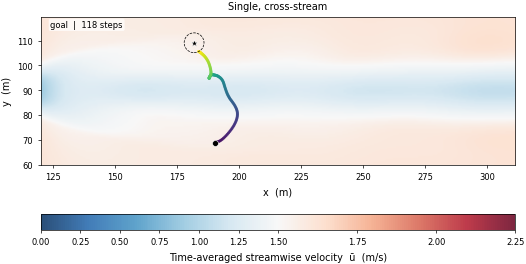

[render fig3_2_single_upstream]
  [saved] figures/arrival_v2_strict_control_validation/fig3_2_single_upstream.pdf
  [saved] figures/arrival_v2_strict_control_validation/fig3_2_single_upstream.png


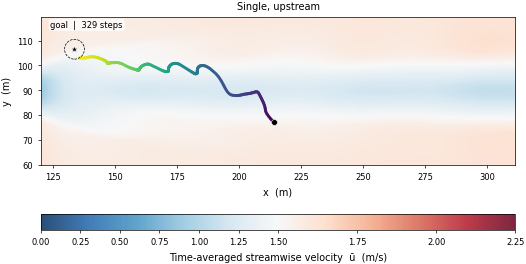

[render fig3_3_tandem]
  [saved] figures/arrival_v2_strict_control_validation/fig3_3_tandem.pdf
  [saved] figures/arrival_v2_strict_control_validation/fig3_3_tandem.png


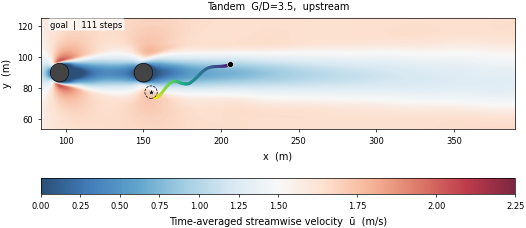

[render fig3_4_sbs]
  [saved] figures/arrival_v2_strict_control_validation/fig3_4_sbs.pdf
  [saved] figures/arrival_v2_strict_control_validation/fig3_4_sbs.png


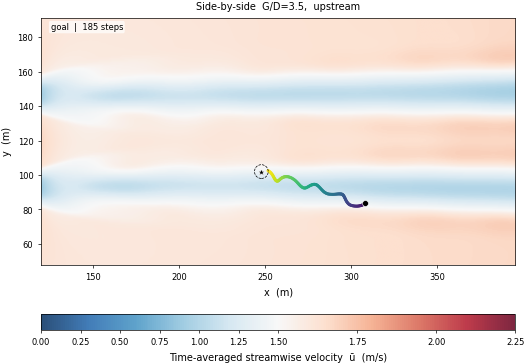

In [10]:
def time_averaged_streamwise(flow_path):
    """Return (u_mean, v_mean, omega_mean, extent, U_inf, wf).

    U_inf is read from the co-located meta.json (`U_ref` key); WakeFieldMetadata
    only stores the geometry/timing slice we need for the env, not U.
    """
    flow_path = Path(flow_path)
    meta_path = flow_path.with_name(flow_path.stem + '_meta.json')
    meta = json.loads(meta_path.read_text(encoding='utf-8')) if meta_path.exists() else {}
    U_inf = float(meta.get('U_ref', 1.5))

    wf = WakeField.from_files(flow_path, None)
    flow = wf.flow  # (T, Nx, Ny, C); C = (u, v, omega)
    u = flow[..., 0].mean(axis=0).T  # transpose to (Ny, Nx) for imshow
    v = flow[..., 1].mean(axis=0).T
    omega = flow[..., 2].mean(axis=0).T
    extent = (wf.x_min, wf.x_max, wf.y_min, wf.y_max)
    return u, v, omega, extent, U_inf, wf

def cylinder_centres(topology, Re=250.0, U_inf=1.5):
    """Return list of (x_c, y_c, R_c) tuples for cylinders in this ROI.

    Single  : navigation profile  cyl_x=96 m, cyl_y=90 m, D=12 m
    Tandem  : make_tandem_physics_config + extra_cylinders
    SBS     : make_side_by_side_physics_config + extra_cylinders
    """
    if topology == 'single':
        return [(96.0, 90.0, 6.0)]
    if topology == 'tandem':
        from scripts.generate_wake import make_tandem_physics_config
        pc = make_tandem_physics_config(Re=Re, U_phys=U_inf)
    elif topology == 'side_by_side':
        from scripts.generate_wake import make_side_by_side_physics_config
        pc = make_side_by_side_physics_config(Re=Re, U_phys=U_inf)
    else:
        raise ValueError(f'unknown topology: {topology}')
    cyls = [(pc.cyl_x_phys, pc.cyl_y_center + pc.cyl_y_jitter, pc.D_phys / 2.0)]
    for x, y, d in pc.extra_cylinders:
        cyls.append((x, y, d / 2.0))
    return cyls

def render_trajectory_panel(scenario, ep, fig_index):
    """Render a single-scenario static trajectory + time-averaged ū figure.

    Saved as fig3_<i>_<key>.{pdf,png} with i = fig_index (1-based).
    """
    u_mean, v_mean, omega_mean, extent, U_inf, wf = time_averaged_streamwise(scenario['flow_path'])

    meta_path = Path(scenario['flow_path']).with_name(Path(scenario['flow_path']).stem + '_meta.json')
    Re_value = 250.0
    if meta_path.exists():
        Re_value = float(json.loads(meta_path.read_text(encoding='utf-8')).get('Re', 250.0))

    fig, ax = plt.subplots(
        figsize=(FIGURE_WIDTH_IN, FIGURE_WIDTH_IN * 0.85),
    )
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(scenario['label'], fontsize=PANEL_TITLE_FS)

    norm = TwoSlopeNorm(vmin=0.0, vcenter=U_inf, vmax=max(float(u_mean.max()), 1.5 * U_inf))
    im = ax.imshow(
        u_mean,
        origin='lower', extent=extent,
        cmap='RdBu_r', norm=norm, alpha=0.85,
        interpolation='bilinear',
    )

    for cx, cy, R in cylinder_centres(scenario['topology'], Re=Re_value, U_inf=U_inf):
        ax.add_patch(Circle((cx, cy), R, facecolor='#444', edgecolor='black', lw=0.4, zorder=3))

    pos = ep['positions']
    progress = np.linspace(0, 1, len(pos))
    ax.scatter(
        pos[:, 0], pos[:, 1], c=progress, cmap='viridis',
        s=1.4, alpha=0.9, zorder=4,
    )

    ax.scatter(*ep['start_xy'], marker='o', color='black', s=18, zorder=5,
               edgecolor='white', lw=0.4)
    ax.scatter(*ep['goal_xy'], marker='*', color='black', s=28, zorder=5,
               edgecolor='white', lw=0.4)
    ax.add_patch(Circle(
        ep['goal_xy'], ep['goal_radius'],
        facecolor='none', edgecolor='black', lw=0.5, ls='--', zorder=4,
    ))

    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_xlabel('x  (m)', fontsize=AXIS_LABEL_FS)
    ax.set_ylabel('y  (m)', fontsize=AXIS_LABEL_FS)
    ax.tick_params(labelsize=TICK_FS)

    success_str = 'goal' if ep['success'] else ep['reason']
    ax.text(0.02, 0.98, f'{success_str}  |  {len(pos)-1} steps',
            transform=ax.transAxes, fontsize=LEGEND_FS,
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, lw=0))

    cbar = fig.colorbar(im, ax=ax, orientation='horizontal',
                        fraction=0.05, pad=0.12, aspect=30)
    cbar.set_label('Time-averaged streamwise velocity  ū  (m/s)',
                   fontsize=AXIS_LABEL_FS)
    cbar.ax.tick_params(labelsize=TICK_FS)

    fig.tight_layout()
    save_figure(fig, f'fig3_{fig_index}_{scenario["key"]}')
    plt.show()
    return fig

for i, sc in enumerate(SCENARIOS, start=1):
    if sc['key'] not in EPISODES:
        print(f'[skip fig3_{i}_{sc["key"]}] no rollout (scenario IN FLIGHT)')
        continue
    print(f'[render fig3_{i}_{sc["key"]}]', flush=True)
    render_trajectory_panel(sc, EPISODES[sc['key']], fig_index=i)

## 9. Figure 4 — 动图 GIF（每场景一个）

每帧：vorticity ω(t) 背景（cmap=RdBu_r 居中 0）+ 圆柱 + AUV trail（最近 30 步）+ AUV 当前位置 marker。

约束：
- GIF 帧宽度严格 138 mm，DPI 100（GIF 适配屏；论文里同一 figure 用 fig3 静态版作 paper）
- FPS 12
- 自动 sub-sample 到最多 200 帧（避免 100MB+ GIF）

缺数据的场景被 skip。

In [11]:
GIF_FPS = 12
GIF_MAX_FRAMES = 200
GIF_TRAIL = 30
GIF_DPI = 100

def render_animation(scenario, ep, save_path):
    """Render a one-panel trajectory + vorticity GIF."""
    env = ep['env']
    wf = env.unwrapped.wake_field if hasattr(env, 'unwrapped') else env.wake_field
    extent = (wf.x_min, wf.x_max, wf.y_min, wf.y_max)
    flow_times_arr = np.asarray(ep['flow_times'])

    n_steps = len(ep['positions'])
    if n_steps > GIF_MAX_FRAMES:
        sample = np.round(np.linspace(0, n_steps - 1, GIF_MAX_FRAMES)).astype(int)
    else:
        sample = np.arange(n_steps)

    # vorticity is the third channel of wf.flow; index by flow_time -> frame
    omega_full = wf.flow[..., 2]  # (T, Nx, Ny)
    T = omega_full.shape[0]
    horizon = float(wf.time_horizon)

    def _omega_at(t):
        idx = int(round((t / horizon) * T)) % T
        return omega_full[idx].T  # (Ny, Nx) for imshow

    omega_stack = np.stack([_omega_at(flow_times_arr[i]) for i in sample], axis=0)
    vmax = float(np.percentile(np.abs(omega_stack), 99))

    # Re / U_inf for cylinder positions
    meta_path = Path(scenario['flow_path']).with_name(Path(scenario['flow_path']).stem + '_meta.json')
    if meta_path.exists():
        meta = json.loads(meta_path.read_text(encoding='utf-8'))
        Re_value = float(meta.get('Re', 250.0))
        U_inf = float(meta.get('U_ref', 1.5))
    else:
        Re_value, U_inf = 250.0, 1.5

    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_WIDTH_IN * 0.55), dpi=GIF_DPI)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_xlabel('x  (m)', fontsize=AXIS_LABEL_FS)
    ax.set_ylabel('y  (m)', fontsize=AXIS_LABEL_FS)
    ax.set_title(scenario['label'], fontsize=PANEL_TITLE_FS)

    im = ax.imshow(
        omega_stack[0], origin='lower', extent=extent,
        cmap='RdBu_r', vmin=-vmax, vmax=vmax,
        interpolation='bilinear', alpha=0.85,
    )
    for cx, cy, R in cylinder_centres(scenario['topology'], Re=Re_value, U_inf=U_inf):
        ax.add_patch(Circle((cx, cy), R, facecolor='#444', edgecolor='black', lw=0.4, zorder=3))

    ax.scatter(*ep['start_xy'], marker='o', color='black', s=14,
               edgecolor='white', lw=0.4, zorder=5)
    ax.scatter(*ep['goal_xy'], marker='*', color='black', s=22,
               edgecolor='white', lw=0.4, zorder=5)
    ax.add_patch(Circle(
        ep['goal_xy'], ep['goal_radius'],
        facecolor='none', edgecolor='black', lw=0.4, ls='--', zorder=4,
    ))

    trail_line, = ax.plot([], [], color=scenario['color'], lw=1.2, zorder=6)
    head_dot, = ax.plot([], [], 'o', color=scenario['color'], ms=3.5, zorder=7,
                        markeredgecolor='white', markeredgewidth=0.4)
    text_box = ax.text(
        0.02, 0.98, '', transform=ax.transAxes,
        fontsize=LEGEND_FS, va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, lw=0),
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.022, pad=0.02)
    cbar.set_label('vorticity ω (1/s)', fontsize=AXIS_LABEL_FS)
    cbar.ax.tick_params(labelsize=TICK_FS)

    fig.tight_layout()

    frames = []
    pos = ep['positions']
    for k, idx in enumerate(sample):
        im.set_data(omega_stack[k])
        i0 = max(0, idx - GIF_TRAIL)
        trail_line.set_data(pos[i0:idx + 1, 0], pos[i0:idx + 1, 1])
        head_dot.set_data([pos[idx, 0]], [pos[idx, 1]])
        text_box.set_text(
            f't = {ep["times"][idx]:6.1f} s    '
            f'd_goal = {np.linalg.norm(pos[idx] - ep["goal_xy"]):5.1f} m'
        )
        fig.canvas.draw()
        # convert canvas to RGB array compatible with both old/new mpl backends
        try:
            buf = np.asarray(fig.canvas.buffer_rgba(), dtype=np.uint8)[:, :, :3]
        except AttributeError:
            w, h = fig.canvas.get_width_height()
            buf = (np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
                     .reshape((h, w, 3)))
        frames.append(buf.copy())

    plt.close(fig)

    imageio.mimsave(save_path, frames, fps=GIF_FPS, loop=0)
    return len(frames), save_path

for sc in SCENARIOS:
    if sc['key'] not in EPISODES:
        print(f'[skip {sc["key"]}] no rollout')
        continue
    out_path = FIG_DIR / f'fig4_animation_{sc["key"]}.gif'
    print(f'[render {sc["key"]}] -> {out_path} ...', flush=True)
    n_frames, _ = render_animation(sc, EPISODES[sc['key']], str(out_path))
    size_mb = out_path.stat().st_size / 1e6
    print(f'  -> {n_frames} frames, {size_mb:.2f} MB')

[render single_cross] -> figures/arrival_v2_strict_control_validation/fig4_animation_single_cross.gif ...


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:107: RuntimeWarning: overflow encountered in cast
  get_virtual_index=lambda n, quantiles: (n - 1) * quantiles,
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4876: RuntimeWarning: overflow encountered in cast
  indexes_above_bounds = virtual_indexes >= valid_values_count - 1
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4781: RuntimeWarning: invalid value encountered in multiply
  lerp_interpolation = asanyarray(add(a, diff_b_a * t, out=out))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4782: RuntimeWarning: invalid value encountered in scalar multiply
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,


  -> 119 frames, 4.55 MB
[render single_upstream] -> figures/arrival_v2_strict_control_validation/fig4_animation_single_upstream.gif ...
  -> 200 frames, 8.17 MB
[render tandem] -> figures/arrival_v2_strict_control_validation/fig4_animation_tandem.gif ...
  -> 112 frames, 3.90 MB
[render sbs] -> figures/arrival_v2_strict_control_validation/fig4_animation_sbs.gif ...
  -> 186 frames, 11.51 MB


## 10. Output manifest

把所有 figure 的元数据 dump 成 JSON，方便论文成稿时引用。

In [12]:
manifest = {
    'experiment': 'arrival_v2_strict_control_validation',
    'control_axes': 's1 / k4 / arrival_v2 / U=1.5 / target=1.5 / seed=42 / 1M / num_envs=6',
    'variable_axis': 'topology x geometry',
    'report_section': 'docs/arrival_v2_experiment_report.md §7',
    'figure_dir': str(FIG_DIR.resolve()),
    'figure_width_mm': FIGURE_WIDTH_MM,
    'figure_width_in': FIGURE_WIDTH_IN,
    'episode_idx': EPISODE_IDX,
    'scenarios': [
        {
            'key': sc['key'],
            'label': sc['label'],
            'topology': sc['topology'],
            'available_full': bool(sc['available_full']),
            'has_rollout': bool(sc['key'] in EPISODES),
        }
        for sc in SCENARIOS
    ],
    'figures': sorted([str(p.relative_to(FIG_DIR)) for p in FIG_DIR.glob('*') if p.is_file()]),
}
manifest_path = FIG_DIR / 'manifest.json'
manifest_path.write_text(json.dumps(manifest, indent=2), encoding='utf-8')
print(f'[saved] {manifest_path}')
print()
print('--- contents ---')
print(json.dumps(manifest, indent=2))

[saved] figures/arrival_v2_strict_control_validation/manifest.json

--- contents ---
{
  "experiment": "arrival_v2_strict_control_validation",
  "control_axes": "s1 / k4 / arrival_v2 / U=1.5 / target=1.5 / seed=42 / 1M / num_envs=6",
  "variable_axis": "topology x geometry",
  "report_section": "docs/arrival_v2_experiment_report.md \u00a77",
  "figure_dir": "/content/drive/MyDrive/Colab Notebooks/new_offRL/rl_v2_5/figures/arrival_v2_strict_control_validation",
  "figure_width_mm": 138.0,
  "figure_width_in": 5.433070866141732,
  "episode_idx": 0,
  "scenarios": [
    {
      "key": "single_cross",
      "label": "Single, cross-stream",
      "topology": "single",
      "available_full": true,
      "has_rollout": true
    },
    {
      "key": "single_upstream",
      "label": "Single, upstream",
      "topology": "single",
      "available_full": true,
      "has_rollout": true
    },
    {
      "key": "tandem",
      "label": "Tandem  G/D=3.5,  upstream",
      "topology": "tandem",